In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geemap
import folium
import contextily as ctx
import osmnx as ox
import networkx as nx   
from folium.plugins import MarkerCluster
import util
import importlib


# Exploration of the Macklin et al., 2023 mines

<Axes: >

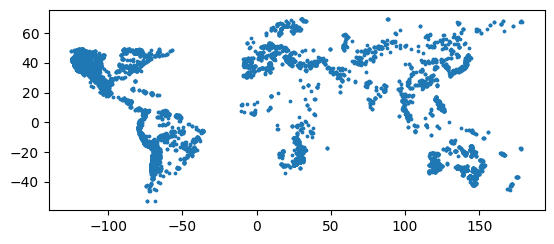

In [2]:
mines = pd.read_excel('data\Macklin_2023\world_active_mines_17.05.2023.xlsx')

mines_geo = gpd.GeoDataFrame(mines, geometry=gpd.points_from_xy(mines.Longitude, mines.Latitude))



mines_geo.plot(marker='o', markersize=3)


First we want to study some spatial characteristics. E.g. spatial density.

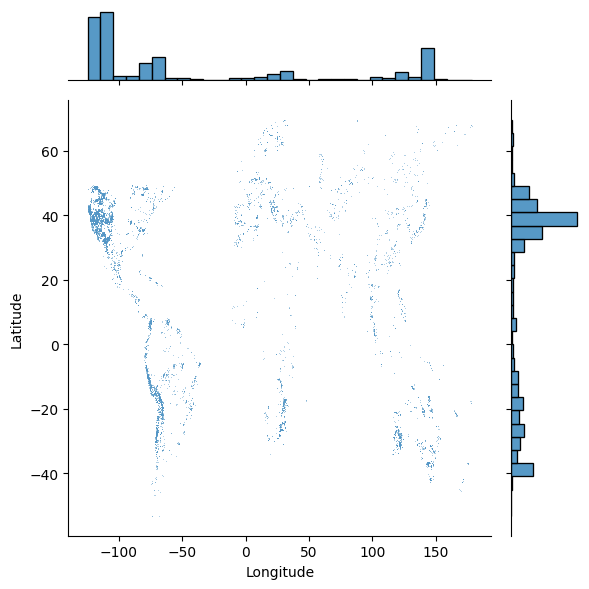

In [3]:
# Generate scatter plot


#f, ax = plt.subplots(1, figsize=(12, 8))  # Update the figsize parameter with your desired figure size


sns.jointplot(x="Longitude", y="Latitude", data=mines_geo, s=0.5, alpha=0.5, marker='o')


# #ctx.add_basemap(
#     joint_axes.ax_joint,
#     crs="EPSG:4326",
#     source=ctx.providers.CartoDB.PositronNoLabels,
# )
plt.tight_layout()

<Axes: >

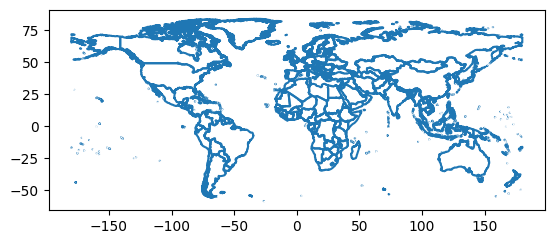

In [18]:
# import the world boundaries
world = gpd.read_file('data\world_bound\world-administrative-boundaries.shp')

# Plot only the boundaries
world.boundary.plot()



C:\Users\admin\AppData\Local\Temp\ipykernel_99240\121619949.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


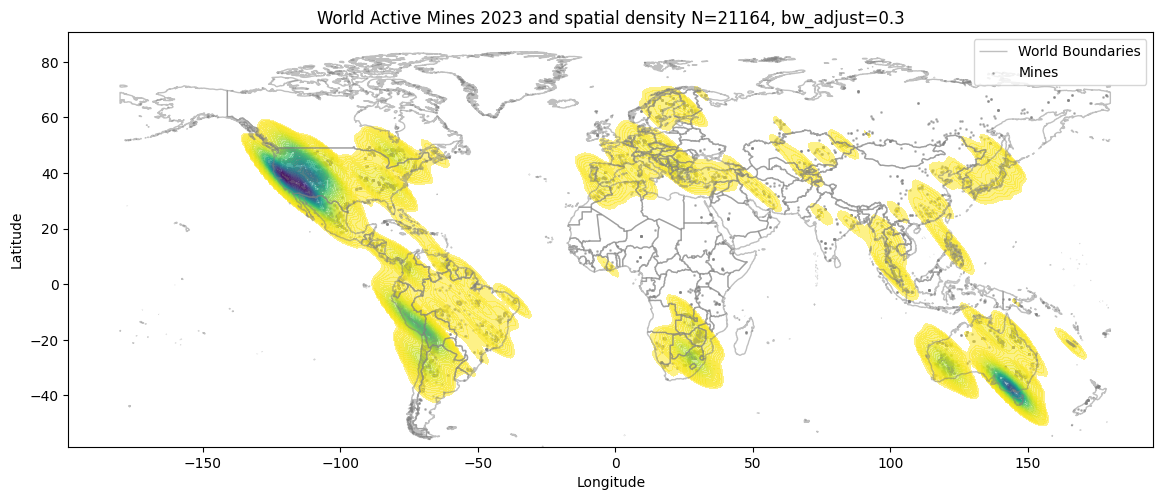

In [5]:

   
# Set up figure and axis
f, ax = plt.subplots(1, figsize=(14, 9))
# Generate and add KDE with a shading of 50 gradients
# coloured contours, 75% of transparency,
# and the reverse viridis colormap

world.boundary.plot(ax = ax, color='grey', linewidth=1, alpha=0.5, label='World Boundaries')

mines_geo.plot(
    ax=ax,
    marker="o",
    markersize=1,
    alpha=0.5,
    label="Mines",
    color="grey",
)

sns.kdeplot(
    x="Longitude",
    y="Latitude",
    data=mines_geo,
    n_levels=50,
    shade=True,
    alpha=0.55,
    cmap="viridis_r",
    ax=ax,
    bw_adjust=.3,
    fill = False
)



plt.title(f'World Active Mines 2023 and spatial density N={mines_geo.shape[0]}, bw_adjust=0.3')

plt.legend(loc='upper right')

plt.savefig('fig\world_active_mines_2023_kde.png', dpi=300)


In [6]:
com_count = mines_geo.groupby('Commodity')['Mine Name'].count().sort_values(ascending=False)

com_count.to_csv('data\output\commodity_macklin_class.csv')

<Axes: >

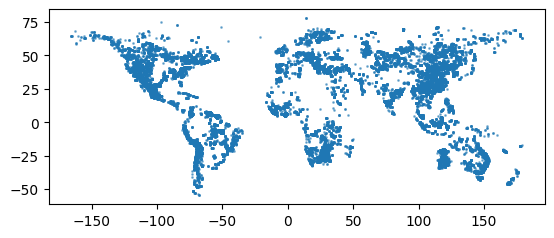

In [2]:
mine_poly = gpd.read_file("data\global_mining_polygons_v2.gpkg")

mine_poly = mine_poly.to_crs(epsg=4326)

mine_poly['centroid'] = mine_poly['geometry'].to_crs(epsg=3857).centroid.to_crs(epsg=4326)

mine_poly['centroid'].plot(marker='o', markersize=1, alpha=0.5)

<Axes: >

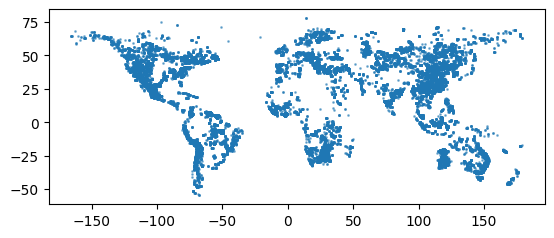

C:\Users\admin\AppData\Local\Temp\ipykernel_99240\2072410677.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


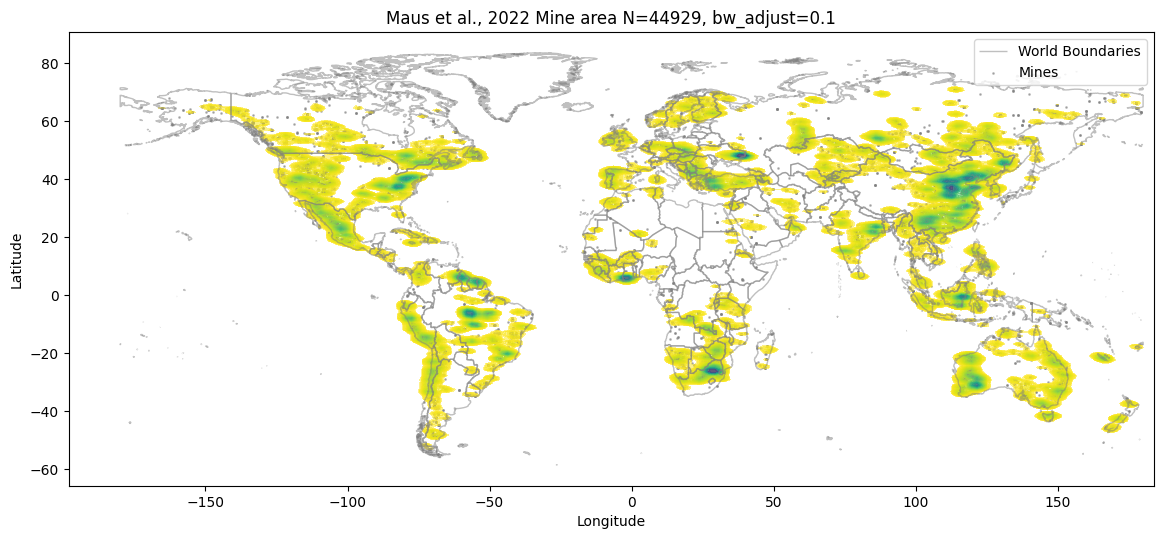

In [18]:

   
# Set up figure and axis
f, ax = plt.subplots(1, figsize=(14, 9))
# Generate and add KDE with a shading of 50 gradients
# coloured contours, 75% of transparency,
# and the reverse viridis colormap

world.boundary.plot(ax = ax, color='grey', linewidth=1, alpha=0.5, label='World Boundaries')

mine_poly['centroid'].plot(
    ax=ax,
    marker="o",
    markersize=1,
    alpha=0.5,
    label="Mines",
    color="grey",
)
bw_factor = 0.1
sns.kdeplot(
    x=mine_poly['centroid'].x,
    y=mine_poly['centroid'].y,
    data=mines_geo,
    n_levels=50,
    shade=True,
    alpha=0.55,
    cmap="viridis_r",
    ax=ax,
    bw_adjust=bw_factor,
    fill = False
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title(f'Maus et al., 2022 Mine area N={mine_poly.shape[0]}, bw_adjust={bw_factor}')

plt.legend(loc='upper right')

plt.savefig('fig\mine area_kde.png', dpi=300)


In [10]:
mine_poly.head()

,ISO3_CODE,COUNTRY_NAME,AREA,geometry,centroid
0,GBR,United Kingdom,1.782044,"POLYGON ((-1.67130 55.07660, -1.67040 55.07710...",POINT (-1.66806 55.07616)
1,FJI,Fiji,0.023405,"POLYGON ((177.85480 -17.51730, 177.85490 -17.5...",POINT (177.85569 -17.51778)
2,NZL,New Zealand,0.042758,"POLYGON ((175.87200 -37.34490, 175.87180 -37.3...",POINT (175.87225 -37.34616)
3,FJI,Fiji,0.248552,"POLYGON ((177.84260 -17.51850, 177.84370 -17.5...",POINT (177.84573 -17.51817)
4,FJI,Fiji,0.132724,"POLYGON ((177.84950 -17.49510, 177.84920 -17.4...",POINT (177.85103 -17.49514)


['Russian Federation',
 'China',
 'Australia',
 'United States',
 'Indonesia',
 'Brazil',
 'Canada',
 'Chile',
 'South Africa',
 'Peru',
 'Guyana',
 'Argentina',
 'India',
 'Myanmar/Burma',
 'Kazakhstan',
 'Suriname',
 'Ghana',
 'Venezuela',
 'Mexico',
 'Ukraine']

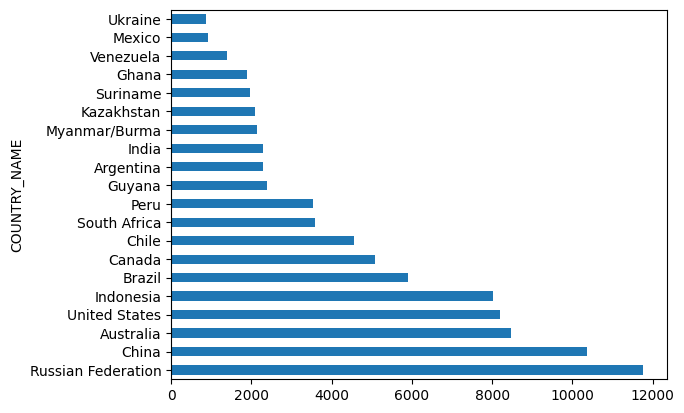

In [11]:
mean_country = mine_poly.groupby('COUNTRY_NAME')['AREA'].sum().sort_values(ascending=False)

mean_country.head(20).plot(kind ='barh')

top_20 = list(mean_country.head(20).index)

top_20

C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3553: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


<Axes: ylabel='name'>

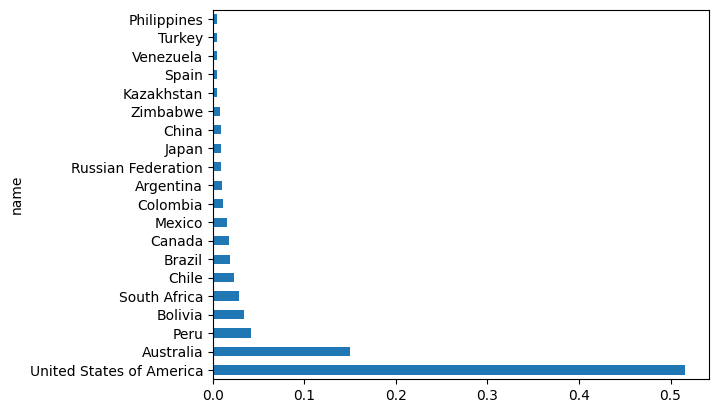

In [12]:
world = world.to_crs(epsg=4326)

world_join = world.sjoin(mines_geo, how='inner', op='intersects')

mines_perc = world_join.groupby('name')['Mine Name'].count().sort_values(ascending=False)

mines_perc = mines_perc / mines_perc.sum()

mines_perc.head(20).plot(kind='barh')

<Axes: >

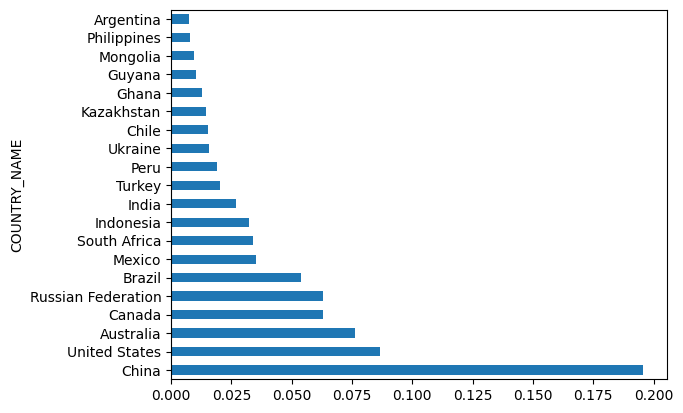

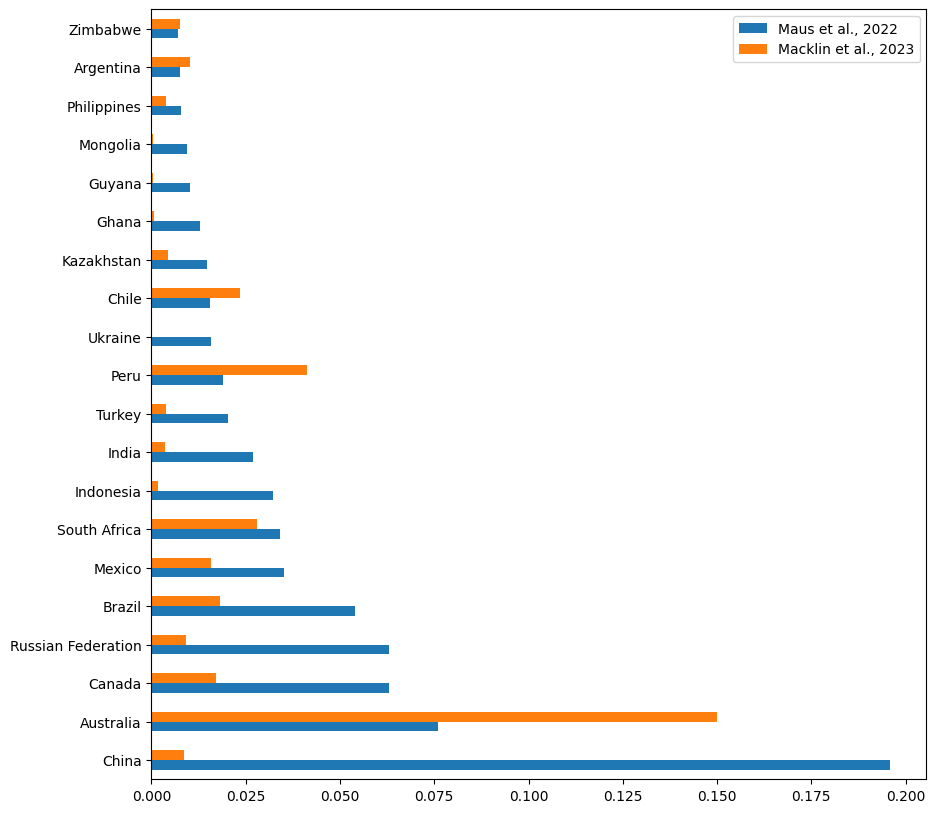

In [13]:
mines_perpol= mine_poly.groupby('COUNTRY_NAME')['AREA'].count().sort_values(ascending=False)

mines_perpol = mines_perpol / mines_perpol.sum()

mines_perpol.head(20).plot(kind='barh')


join_c = pd.DataFrame(mines_perpol).merge(mines_perc, left_index=True, right_index=True)

join_c.rename(columns={'AREA':'Maus et al., 2022', 'Mine Name':'Macklin et al., 2023'}, inplace=True)

join_c.head(20).plot(kind='barh', figsize=(10, 10), color=['#1f77b4', '#ff7f0e'])

* it looks like the Macklin data underestimates the total mines in the world. 
* Macklin data has an tremendous bias towards the United states and underestimates russia and australia quite a bit. 
* Important note is that Macklin has no Cole & Iron as important commodities.

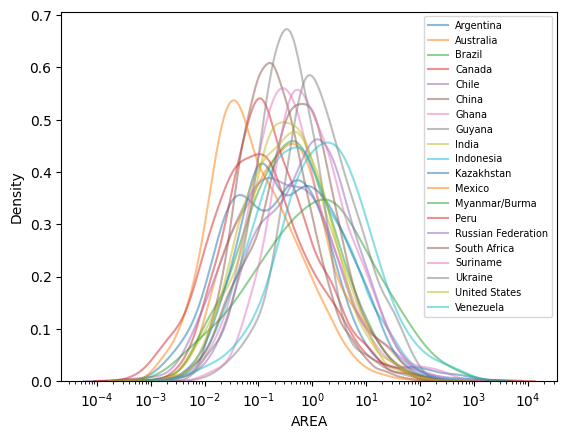

In [14]:
for name, group in mine_poly.groupby('COUNTRY_NAME'):
    if name in top_20:
        sns.kdeplot(group['AREA'], label=name,alpha=0.5, log_scale=True)

plt.legend(loc='upper right', fontsize=7)

We see the distribution of the area per country is normal.



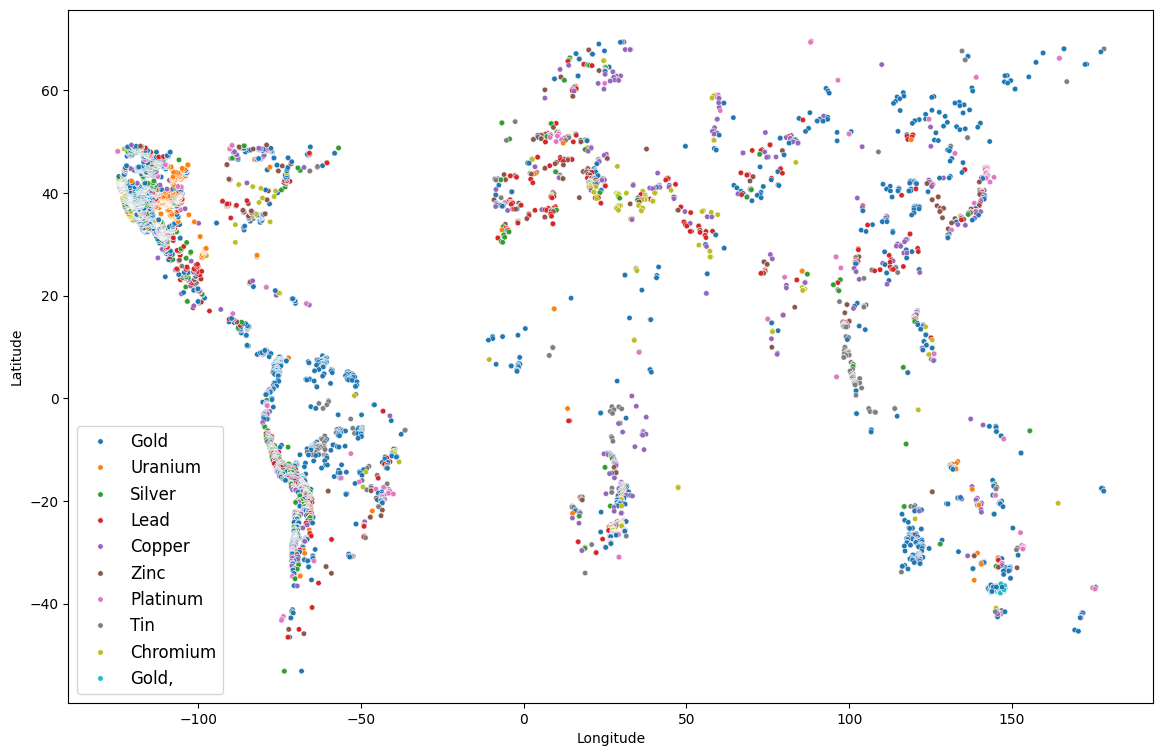

In [15]:
top_10Com = mines_geo['Commodity'].value_counts().head(10).index.tolist()

f, ax = plt.subplots(1, figsize=(14, 9))

sns.scatterplot(ax=ax, data=mines_geo[mines_geo['Commodity'].isin(top_10Com)], x='Longitude', y='Latitude', hue='Commodity', s=15, palette='tab10')


# Adjust the legend size
ax.legend(fontsize='large')


In [4]:
mine_poly.head()

,ISO3_CODE,COUNTRY_NAME,AREA,geometry,centroid
0,GBR,United Kingdom,1.782044,"POLYGON ((-1.67130 55.07660, -1.67040 55.07710...",POINT (-1.66806 55.07616)
1,FJI,Fiji,0.023405,"POLYGON ((177.85480 -17.51730, 177.85490 -17.5...",POINT (177.85569 -17.51778)
2,NZL,New Zealand,0.042758,"POLYGON ((175.87200 -37.34490, 175.87180 -37.3...",POINT (175.87225 -37.34616)
3,FJI,Fiji,0.248552,"POLYGON ((177.84260 -17.51850, 177.84370 -17.5...",POINT (177.84573 -17.51817)
4,FJI,Fiji,0.132724,"POLYGON ((177.84950 -17.49510, 177.84920 -17.4...",POINT (177.85103 -17.49514)


In [43]:




title_html = '''
             <h3 align="center" style="font-size:20px"><b>Mine Areas sccording to Maus et al., 2022</b></h3>
             '''




map = folium.Map(location=[0, 0], zoom_start=2)

#folium.TileLayer('Stamen Terrain', attr='Stamen Terrain').add_to(map)

#folium.LayerControl().add_to(map)

map.get_root().html.add_child(folium.Element(title_html))


cluster = MarkerCluster().add_to(map)

for idx, row in mine_poly.iterrows():
    popup = f"Area in km2: {row['AREA']}, Country: {row['COUNTRY_NAME']}, Location: {row['centroid']}"
    folium.Marker(
        location=[row['centroid'].y, row['centroid'].x],
        popup=popup,
        icon=folium.Icon(color='red', icon='star')
    ).add_to(cluster)



map.save("fig\poly_map.html")

In [15]:

from folium import plugins

map_heat = folium.Map(location = [0,0], tiles='Cartodb dark_matter', zoom_start = 2)

heat_data = [[point.y ,point.x] for point in mine_poly.centroid ]

plugins.HeatMap(heat_data, 
                name='mine_area',
                min_opacity=.2,
                blur = 10,
                radius=10,
                max_zoom=1
                ).add_to(map_heat)

map_heat.save("fig\poly_map_heat.html")



C:\Users\admin\AppData\Local\Temp\ipykernel_101576\1467748086.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  heat_data = [[point.y ,point.x] for point in mine_poly.centroid ]


### No lets do a cloropleth.

In [19]:
world.head()

,iso3,status,color_code,name,continent,region,iso_3166_1_,french_shor,geometry
0,UGA,Member State,UGA,Uganda,Africa,Eastern Africa,UG,Ouganda,"POLYGON ((33.92110 -1.00194, 33.92027 -1.00111..."
1,UZB,Member State,UZB,Uzbekistan,Asia,Central Asia,UZ,Ouzbékistan,"POLYGON ((70.97081 42.25467, 70.98054 42.26205..."
2,IRL,Member State,IRL,Ireland,Europe,Northern Europe,IE,Irlande,"MULTIPOLYGON (((-9.97014 54.02083, -9.93833 53..."
3,ERI,Member State,ERI,Eritrea,Africa,Eastern Africa,ER,Érythrée,"MULTIPOLYGON (((40.13583 15.75250, 40.12861 15..."
4,None,UK Territory,GBR,South Georgia & the South Sandwich Islands,Antarctica,None,None,South Georgia & the South Sandwich Islands,"MULTIPOLYGON (((-26.24361 -58.49473, -26.24889..."


C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\IPython\core\interactiveshell.py:3553: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


<Axes: >

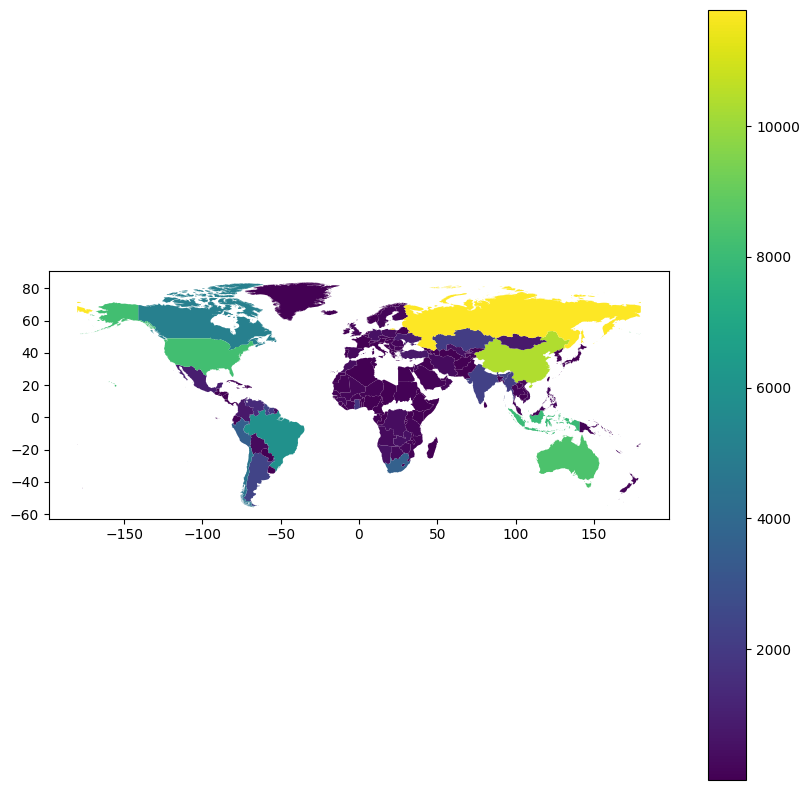

In [28]:
world_join = world.sjoin(mine_poly, how='inner', op='intersects')

world_join.head()

world_joinGroup = world_join.groupby('name')['AREA'].sum().reset_index().merge(world[['name', 'geometry']], left_on='name', right_on='name')

world_joinGroup = gpd.GeoDataFrame(world_joinGroup, geometry='geometry')



C:\Users\admin\AppData\Local\Temp\ipykernel_101576\344460194.py:1: FutureWarning: 'colormap' is deprecated, please use 'cmap' instead (for consistency with matplotlib)
  world_joinGroup.plot(column='AREA',


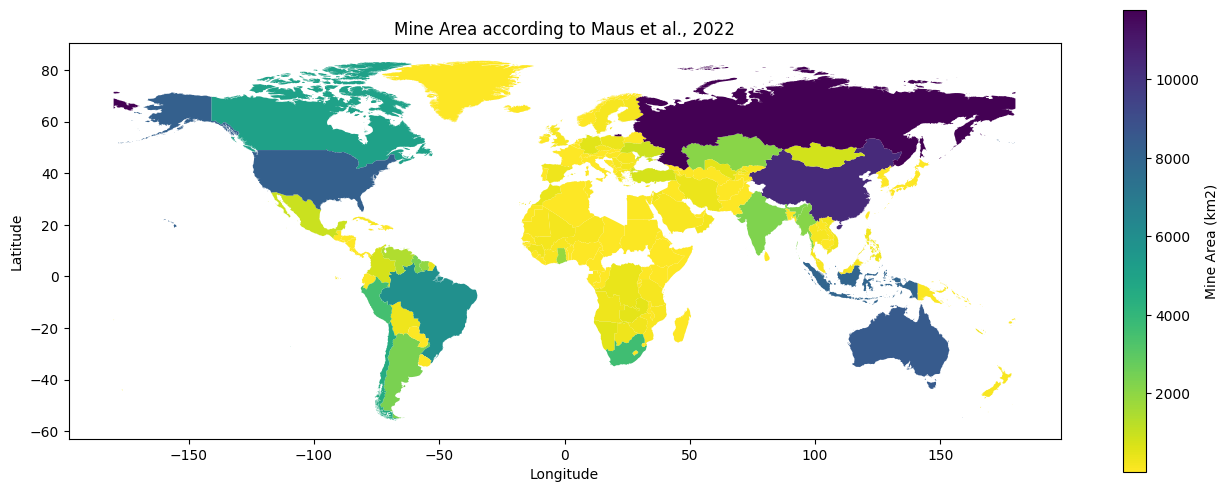

In [36]:
world_joinGroup.plot(column='AREA', 
                    legend=True,
                    legend_kwds={'label': "Mine Area (km2)"},
                    figsize=(16, 6),
                    colormap='viridis_r'
                    )
                    
plt.title('Mine Area according to Maus et al., 2022')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig('fig\world_mine_area_cloropleth.png', dpi=300)


In [42]:
mine_poly.head()

,ISO3_CODE,COUNTRY_NAME,AREA,geometry,centroid
0,GBR,United Kingdom,1.782044,"POLYGON ((-1.67130 55.07660, -1.67040 55.07710...",POINT (-1.66806 55.07616)
1,FJI,Fiji,0.023405,"POLYGON ((177.85480 -17.51730, 177.85490 -17.5...",POINT (177.85569 -17.51778)
2,NZL,New Zealand,0.042758,"POLYGON ((175.87200 -37.34490, 175.87180 -37.3...",POINT (175.87225 -37.34616)
3,FJI,Fiji,0.248552,"POLYGON ((177.84260 -17.51850, 177.84370 -17.5...",POINT (177.84573 -17.51817)
4,FJI,Fiji,0.132724,"POLYGON ((177.84950 -17.49510, 177.84920 -17.4...",POINT (177.85103 -17.49514)


In [14]:
gemap = geemap.Map(center=[0, 0], zoom=2)
gemap


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

###Network analysis

As a proxy for the secondary land use we study the road network in an 100km distances 

In [8]:
# first lets get a sample

#mine_met = mine_poly.to_crs(epsg=3857)


In [32]:
mine_samp = mine_poly.sample(100)

<Axes: >

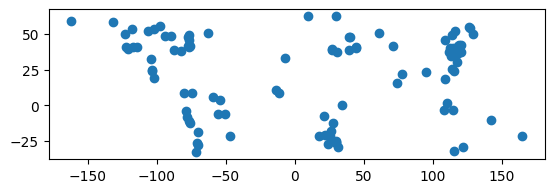

In [33]:
mine_samp.centroid.plot()

In [68]:

def get_network(mines):
    m = folium.Map(location=[0, 0], zoom_start=2)
    cluster = MarkerCluster().add_to(m)

    count_suc =0
    count_fail = 0  
    
    for p in mines: 
        try:
            # Simplification of the network to retain only the nodes that represent junctions to streets.
            G_drive = ox.graph_from_point((p.y, p.x), dist=20000, network_type='drive', simplify=True)
            
            # Plot the mine location
            folium.Marker(
                location=[p.y, p.x],
                popup='Mine Location',
                icon=folium.Icon(color='red', icon='star')
            ).add_to(cluster)
            
            # Plot the network
            ox.plot_graph_folium(G_drive, graph_map=m, popup_attribute=None)
            
            
            count_suc += 1
        except (ox._errors.InsufficientResponseError, ValueError, nx.NetworkXPointlessConcept):
            count_fail += 1
            continue

        
        print(f'success {count_suc/len(mines)} fail {count_fail / len(mines)}')
    return m

map = get_network(mine_poly.sample(20).centroid.values)


map.save("fig/test_network.html")


success 0.05 fail 0.0
success 0.1 fail 0.1
success 0.15 fail 0.1
success 0.2 fail 0.1
success 0.25 fail 0.1
success 0.3 fail 0.1
success 0.35 fail 0.1
success 0.4 fail 0.1
success 0.45 fail 0.1
success 0.5 fail 0.1
success 0.55 fail 0.1
success 0.6 fail 0.1
success 0.65 fail 0.1
success 0.7 fail 0.1
success 0.75 fail 0.1
success 0.8 fail 0.1
success 0.85 fail 0.1
success 0.9 fail 0.1


In [67]:
map.save("fig/test_network.html")

In [28]:
mine_samp.head()

,ISO3_CODE,COUNTRY_NAME,AREA,geometry,centroid
39432,LKA,Sri Lanka,0.002296,"POLYGON ((8910421.476 737482.369, 8910414.908 ...",POINT (80.04387 6.61004)
40110,GBR,United Kingdom,0.078986,"POLYGON ((-384062.596 6710729.100, -384174.917...",POINT (-3.45177 51.50129)
31324,MLI,Mali,0.394576,"POLYGON ((-1244057.982 1426601.624, -1244122.5...",POINT (-11.17364 12.70569)
6909,IND,India,0.024577,"POLYGON ((9769342.852 2887872.573, 9769498.700...",POINT (87.76047 25.09937)
30726,IDN,Indonesia,4.632684,"POLYGON ((13064588.244 222966.798, 13066059.66...",POINT (117.35340 2.00270)


Trouble shoot the street network class

In [5]:
mine_poly.head()

,ISO3_CODE,COUNTRY_NAME,AREA,geometry,centroid
0,GBR,United Kingdom,1.782044,"POLYGON ((-1.67130 55.07660, -1.67040 55.07710...",POINT (-1.66806 55.07616)
1,FJI,Fiji,0.023405,"POLYGON ((177.85480 -17.51730, 177.85490 -17.5...",POINT (177.85569 -17.51778)
2,NZL,New Zealand,0.042758,"POLYGON ((175.87200 -37.34490, 175.87180 -37.3...",POINT (175.87225 -37.34616)
3,FJI,Fiji,0.248552,"POLYGON ((177.84260 -17.51850, 177.84370 -17.5...",POINT (177.84573 -17.51817)
4,FJI,Fiji,0.132724,"POLYGON ((177.84950 -17.49510, 177.84920 -17.4...",POINT (177.85103 -17.49514)


In [11]:
np.random.seed(42)

mine_samp = mine_poly.sample(10)

In [13]:
import sys
sys.path

['c:\\Users\\admin\\Documents\\DCRM\\DCRM',
 'c:\\Users\\admin\\AppData\\Local\\Programs\\Python\\Python311\\python311.zip',
 'c:\\Users\\admin\\AppData\\Local\\Programs\\Python\\Python311\\DLLs',
 'c:\\Users\\admin\\AppData\\Local\\Programs\\Python\\Python311\\Lib',
 'c:\\Users\\admin\\AppData\\Local\\Programs\\Python\\Python311',
 '',
 'C:\\Users\\admin\\AppData\\Roaming\\Python\\Python311\\site-packages',
 'C:\\Users\\admin\\AppData\\Roaming\\Python\\Python311\\site-packages\\win32',
 'C:\\Users\\admin\\AppData\\Roaming\\Python\\Python311\\site-packages\\win32\\lib',
 'C:\\Users\\admin\\AppData\\Roaming\\Python\\Python311\\site-packages\\Pythonwin',
 'c:\\Users\\admin\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages']

In [30]:
from util import Street_network

ImportError: cannot import name 'Street_network' from 'util' (c:\Users\admin\Documents\DCRM\DCRM\util.py)

ImportError: cannot import name 'Street_network' from 'util' (c:\Users\admin\Documents\DCRM\DCRM\util.py)

In [40]:
import os

os.path.abspath('dcrm_exploration.ipynb')



'c:\\Users\\admin\\Documents\\DCRM\\DCRM\\dcrm_exploration.ipynb'

In [41]:
os.getcwd()

'c:\\Users\\admin\\Documents\\DCRM\\DCRM'

,ISO3_CODE,COUNTRY_NAME,AREA,geometry,centroid,street_network,net_properties
37163,MEX,Mexico,0.106841,"POLYGON ((-109.62858 28.25264, -109.62924 28.2...",POINT (-109.62966 28.24965),"MULTILINESTRING ((-109.66294 28.12266, -109.66...","{'average_degree': 0.025355596784168218, 'stdv..."
21958,BRA,Brazil,1.375978,"POLYGON ((-54.65917 -10.48342, -54.65990 -10.4...",POINT (-54.67075 -10.48925),"MULTILINESTRING ((-54.49560 -10.42024, -54.492...","{'average_degree': 0.03403755868544601, 'stdv_..."
41968,RUS,Russian Federation,1.650308,"POLYGON ((125.97127 55.66951, 125.96856 55.669...",POINT (125.97980 55.65764),None,None
31033,KGZ,Kyrgyzstan,1.561641,"POLYGON ((73.88392 42.80463, 73.88323 42.80000...",POINT (73.89033 42.79883),"MULTILINESTRING ((74.09033 42.83345, 74.08873 ...","{'average_degree': 0.000741562975839475, 'stdv..."
30260,GHA,Ghana,0.399266,"POLYGON ((-2.02687 5.19274, -2.02535 5.19177, ...",POINT (-2.02018 5.19467),"MULTILINESTRING ((-1.98413 5.34396, -1.98343 5...","{'average_degree': 0.0009000338478986971, 'std..."
18378,RUS,Russian Federation,0.398537,"POLYGON ((118.16290 50.09600, 118.16480 50.090...",POINT (118.16789 50.09167),"MULTILINESTRING ((117.97109 50.10689, 117.9722...","{'average_degree': 0.00331528665774866, 'stdv_..."
38979,ZAF,South Africa,0.070932,"POLYGON ((27.32247 -24.76922, 27.32227 -24.769...",POINT (27.32027 -24.77143),"MULTILINESTRING ((27.37974 -24.65737, 27.38009...","{'average_degree': 0.0027890801200566996, 'std..."
20152,ARG,Argentina,58.017833,"POLYGON ((-69.09027 -38.80052, -69.09765 -38.8...",POINT (-69.05306 -38.84222),"MULTILINESTRING ((-69.22207 -38.92947, -69.222...","{'average_degree': 0.001123896818437934, 'stdv..."
38440,RUS,Russian Federation,0.088704,"POLYGON ((60.95929 53.06765, 60.95919 53.06687...",POINT (60.96063 53.06589),"MULTILINESTRING ((60.66146 53.07080, 60.66267 ...","{'average_degree': 0.005807410461929677, 'stdv..."
31066,LAO,Laos,0.042143,"POLYGON ((102.14667 18.78286, 102.14755 18.783...",POINT (102.14648 18.78397),"MULTILINESTRING ((102.32683 18.63233, 102.3265...","{'average_degree': 0.004802644370989696, 'stdv..."


NameError: name 'Street_network' is not defined

In [6]:
mine_samp.head()

,ISO3_CODE,COUNTRY_NAME,AREA,geometry,centroid
37163,MEX,Mexico,0.106841,"POLYGON ((-109.62858 28.25264, -109.62924 28.2...",POINT (-109.62966 28.24965)
21958,BRA,Brazil,1.375978,"POLYGON ((-54.65917 -10.48342, -54.65990 -10.4...",POINT (-54.67075 -10.48925)
41968,RUS,Russian Federation,1.650308,"POLYGON ((125.97127 55.66951, 125.96856 55.669...",POINT (125.97980 55.65764)
31033,KGZ,Kyrgyzstan,1.561641,"POLYGON ((73.88392 42.80463, 73.88323 42.80000...",POINT (73.89033 42.79883)
30260,GHA,Ghana,0.399266,"POLYGON ((-2.02687 5.19274, -2.02535 5.19177, ...",POINT (-2.02018 5.19467)


In [71]:
importlib.reload(util)
from util import Rail_network

In [10]:
# Assuming you have a DataFrame called 'mines_df' containing the mine locations and other information
mine_samp['street_network'] = mine_samp.apply(lambda row: Street_network(mine_id=row.name, p=row['centroid'], buffer=20000), axis=1)


In [13]:
mine_samp['graph_spd'] = mine_samp['street_network'].apply(lambda x: x.graph_sdp)

In [72]:
mine_samp = mine_poly.sample(10)

In [25]:
mine_samp['street_network'] = mine_samp.apply(lambda row: Street_network(mine_id=row.name, p=row['centroid'], buffer=20000), axis=1)


In [27]:
mine_samp.head()

,ISO3_CODE,COUNTRY_NAME,AREA,geometry,centroid,street_network
3741,PER,Peru,5.220195,"POLYGON ((-75.15990 -13.19250, -75.15720 -13.1...",POINT (-75.14750 -13.18560),<util.Street_network object at 0x000001C20916D...
42603,GUY,Guyana,1.460662,"POLYGON ((-59.43269 6.48539, -59.43245 6.47762...",POINT (-59.43044 6.47944),<util.Street_network object at 0x000001C1CB121...
12432,CHN,China,0.448522,"POLYGON ((108.03330 35.04550, 108.03330 35.044...",POINT (108.03707 35.04780),<util.Street_network object at 0x000001C1CE4D7...
9602,USA,United States,2.324847,"POLYGON ((-81.89030 38.11340, -81.89210 38.112...",POINT (-81.87306 38.11301),<util.Street_network object at 0x000001C208453...
29670,DOM,Dominican Republic,0.320701,"POLYGON ((-70.18770 18.93556, -70.18974 18.936...",POINT (-70.19084 18.93411),<util.Street_network object at 0x000001C1D4036...


In [73]:
mine_samp['rail_network'] = mine_samp.apply(lambda row: Rail_network(mine_id=row.name, p=row['centroid'], buffer=10*10**3), axis=1)


In [75]:
mine_samp['rail_shp'] = mine_samp['rail_network'].apply(lambda x: x.graph_sdp)

In [70]:
ox.settings.useful_tags_node

['ref', 'highway']

In [40]:
mine_samp['rail_omnx'] = mine_samp['rail_network_1'].apply(lambda x: x.graph_osmnx)


In [51]:
ox.settings.useful_tags_way += ["railway"]

In [52]:
ox.settings.useful_tags_way 

['bridge',
 'tunnel',
 'oneway',
 'lanes',
 'ref',
 'name',
 'highway',
 'maxspeed',
 'service',
 'access',
 'area',
 'landuse',
 'width',
 'est_width',
 'junction',
 'railway',
 'railway',
 'railway',
 'railway']